<a href="https://colab.research.google.com/github/vyshnavivallepu7-code/Machine-learning/blob/main/german_creadit_exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB
     Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0     67    male    2     own             NaN         

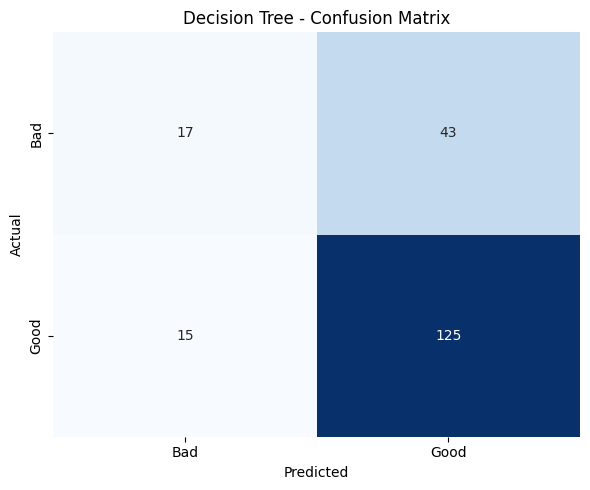

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
#df,info
#df.shape
# ---------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------

file_path = '/content/German_Credit_Card_DataSet (1).csv'

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
print(df.columns)
df.shape
df.info()
df.describe()
# ---------------------------------------------------------
# 2. Target
# ---------------------------------------------------------

df['Risk'] = df['Risk'].astype(str).str.strip().str.lower()

y = df['Risk'].map({
    'good': 1,
    'bad': 0
})

X = df.drop(columns=['Risk'])
print(X)
print(y)
# ---------------------------------------------------------
# 3. Features
# ---------------------------------------------------------

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=[np.number]
).columns.tolist()
# ---------------------------------------------------------
# 4. Preprocessing
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),

        ('cat',
         OneHotEncoder(
             drop='first',
             handle_unknown='ignore'
         ),
         categorical_cols)
    ]
)
# ---------------------------------------------------------
# 5. Decision Tree
# ---------------------------------------------------------

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('classifier',
         DecisionTreeClassifier(
             max_depth=6,
             random_state=42
         ))
    ]
)
# ---------------------------------------------------------
# 6. Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# ---------------------------------------------------------
# 7. Train
# ---------------------------------------------------------

model.fit(X_train, y_train)
# ---------------------------------------------------------
# 8. Prediction
# ---------------------------------------------------------

y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]
# ---------------------------------------------------------
# 9. Evaluation
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

pr_auc = average_precision_score(
    y_test,
    y_proba
)

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\n====================================")
print("DECISION TREE RESULTS")
print("====================================")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Bad (0)', 'Good (1)']
    )
)
# ---------------------------------------------------------
# 10. Confusion Matrix
# ---------------------------------------------------------

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()





